# Практическая работа № 1 (уровень B)
## Первичный анализ датасета tips

**ФИО:** Мырзабекова Айжамал
**Группа:** CS 32-24
**Дата:** 22.09.2026

## О данных

Датасет `tips` (источник: Kaggle) — счета в ресторане.
244 наблюдения, 7 признаков:

- `total_bill` — сумма счёта, $
- `tip` — чаевые, $
- `sex` — пол официанта
- `smoker` — курящий ли клиент
- `day` — день недели
- `time` — обед или ужин
- `size` — размер компании


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print("Библиотеки загружены")


Библиотеки загружены


In [2]:
df = pd.read_csv("../data/tips.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Первичный осмотр


In [3]:
print("Размер таблицы (строки, столбцы):", df.shape)
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")


Размер таблицы (строки, столбцы): (244, 7)
Строк: 244, Столбцов: 7


In [4]:
df.dtypes


total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

In [5]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Визуализация

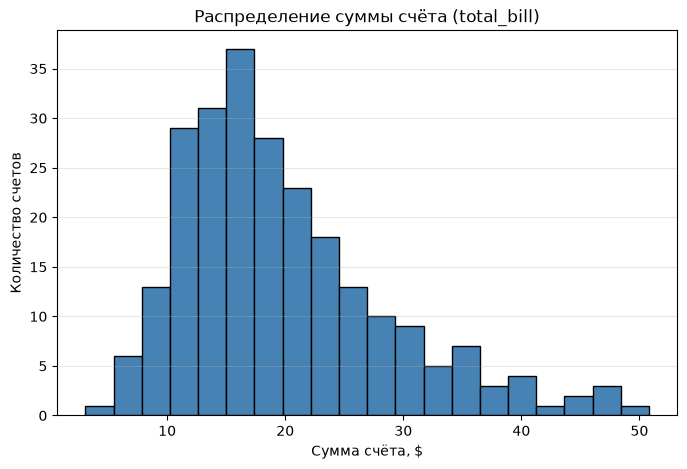

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df["total_bill"], bins=20, color="steelblue", edgecolor="black")
plt.title("Распределение суммы счёта (total_bill)")
plt.xlabel("Сумма счёта, $")
plt.ylabel("Количество счетов")
plt.grid(axis="y", alpha=0.3)
plt.show()

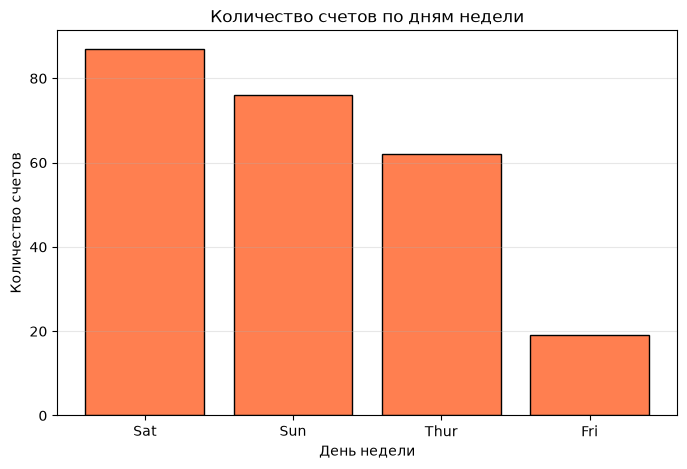

In [8]:
plt.figure(figsize=(8, 5))
day_counts = df["day"].value_counts()
plt.bar(day_counts.index, day_counts.values, color="coral", edgecolor="black")
plt.title("Количество счетов по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество счетов")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [9]:
df.groupby("day")["tip"].mean().round(2)

day
Fri     2.73
Sat     2.99
Sun     3.26
Thur    2.77
Name: tip, dtype: float64

## Наблюдения

1. **Правосторонняя асимметрия `total_bill`.**
   Распределение суммы счёта скошено вправо: большинство чеков
   в диапазоне 10–25 $, но есть «хвост» из крупных счетов 40–50 $.
   Среднее (19.78) заметно выше медианы (17.80) — редкие крупные счета
   тянут среднее вверх. Для ML это означает, что признак, возможно,
   потребует логарифмического преобразования.

2. **Несбалансированность по дням недели.**
   Более 2/3 наблюдений приходится на субботу и воскресенье (Sat + Sun),
   а пятница представлена всего ~19 счетами. Если строить классификатор
   «день недели», он будет смещён к выходным.

3. **Чаевые зависят не только от суммы счёта.**
   В воскресенье средние чаевые 3.26 $, в пятницу — 2.73 $,
   хотя суммы счетов по дням близки. Это указывает на возможное
   взаимодействие признаков (`total_bill` и `day`), которое стоит
   учесть при моделировании.